# TAHAP 6 — Hyperparameter Tuning (Opsional)

Tuning hyperparameter untuk model pemenang dari Tahap 4.
Menggunakan `RandomizedSearchCV` dengan scoring `f1_macro`.

**Input:**
- `data/splits/X_train.csv`, `y_train.csv`, `X_val.csv`, `y_val.csv`
- `models/model_metadata.json`
- `models/isolation_forest.pkl`

**Output (jika tuned lebih baik):**
- Overwrite `models/best_supervised.pkl`
- Update `models/model_metadata.json`

**Setelah tuning:** Jalankan ulang `05_evaluation.ipynb` untuk melihat hasil pada test set.

## Import & Load

In [11]:
import os
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score, make_scorer

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Paths
SPLITS_DIR = os.path.join("..", "data", "splits")
MODELS_DIR = os.path.join("..", "models")
RANDOM_STATE = 42

# Load data
X_train = pd.read_csv(os.path.join(SPLITS_DIR, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(SPLITS_DIR, "X_val.csv"))
y_train = pd.read_csv(os.path.join(SPLITS_DIR, "y_train.csv"))["severity_encoded"]
y_val   = pd.read_csv(os.path.join(SPLITS_DIR, "y_val.csv"))["severity_encoded"]

# Load IF model untuk augment features
if_pipe = joblib.load(os.path.join(MODELS_DIR, "isolation_forest.pkl"))

# Augment dengan IF anomaly score
X_train_aug = X_train.copy()
X_train_aug["if_anomaly_score"] = -if_pipe.decision_function(X_train)
X_val_aug = X_val.copy()
X_val_aug["if_anomaly_score"] = -if_pipe.decision_function(X_val)

# Load metadata
META_PATH = os.path.join(MODELS_DIR, "model_metadata.json")
with open(META_PATH) as f:
    meta = json.load(f)

MODEL_TYPE = meta["model_type"]
MODEL_NAME = meta["model_name"]
DEFAULT_F1 = meta["validation_f1_macro"]
SEVERITY_LABELS = meta["class_labels"]

print(f"[OK] Data loaded")
print(f"     Model pemenang: {MODEL_NAME} (F1-macro default: {DEFAULT_F1:.4f})")
print(f"     Train: {X_train_aug.shape}, Val: {X_val_aug.shape}")

[OK] Data loaded
     Model pemenang: RandomForest (F1-macro default: 0.9433)
     Train: (2030, 12), Val: (435, 12)


## Define Search Space

In [12]:
print("[1/4] Menentukan search space...")

if MODEL_TYPE == "rf":
    param_dist = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", "balanced_subsample"],
    }
    base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    print(f"      Search space untuk Random Forest:")

elif MODEL_TYPE == "xgboost" and XGBOOST_AVAILABLE:
    param_dist = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    }
    base_model = xgb.XGBClassifier(
        objective="multi:softprob", num_class=4,
        eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
    )
    print(f"      Search space untuk XGBoost:")

else:
    raise ValueError(f"Model type '{MODEL_TYPE}' tidak didukung untuk tuning")

for param, values in param_dist.items():
    print(f"        {param}: {values}")

# Hitung total kombinasi
total_combos = 1
for v in param_dist.values():
    total_combos *= len(v)
print(f"\n      Total kemungkinan kombinasi: {total_combos:,}")

[1/4] Menentukan search space...
      Search space untuk Random Forest:
        n_estimators: [100, 200, 300, 500]
        max_depth: [None, 10, 20, 30]
        min_samples_split: [2, 5, 10]
        min_samples_leaf: [1, 2, 4]
        class_weight: ['balanced', 'balanced_subsample']

      Total kemungkinan kombinasi: 288


## RandomizedSearchCV

In [13]:
print("[2/4] Menjalankan RandomizedSearchCV...")
print(f"      30 iterasi x 5-fold CV (scoring: f1_macro)")
print(f"      Ini bisa memakan waktu beberapa menit...")

scorer = make_scorer(f1_score, average="macro")

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring=scorer,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_aug, y_train)

print(f"\n      Tuning selesai!")
print(f"      Best CV F1-macro: {search.best_score_:.4f}")
print(f"      Best params: {search.best_params_}")

[2/4] Menjalankan RandomizedSearchCV...
      30 iterasi x 5-fold CV (scoring: f1_macro)
      Ini bisa memakan waktu beberapa menit...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



      Tuning selesai!
      Best CV F1-macro: 0.9464
      Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced_subsample'}


## Perbandingan Default vs Tuned

[3/4] Membandingkan default vs tuned pada validation set...

  Perbandingan F1-macro (Validation Set):
    Default: 0.9433
    Tuned  : 0.9168
    Penurunan: -0.0266


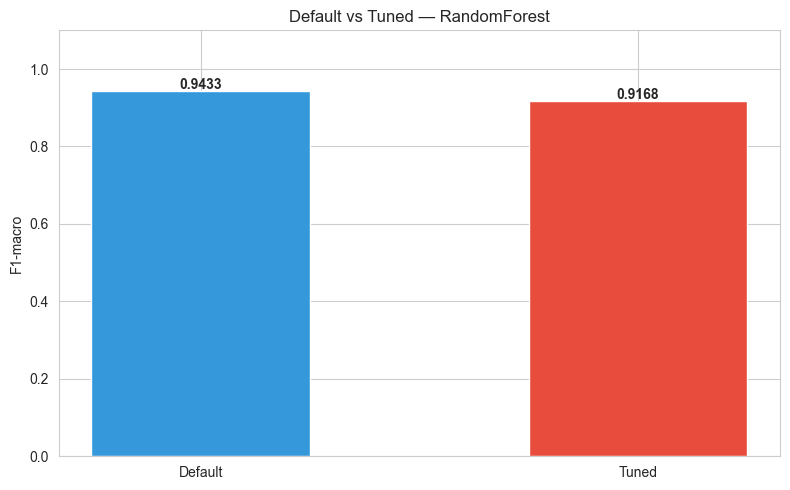


  Classification Report (Tuned, Validation Set):
              precision    recall  f1-score   support

         LOW      0.984     0.984     0.984       375
      MEDIUM      0.871     1.000     0.931        27
        HIGH      0.875     0.778     0.824        18
    CRITICAL      1.000     0.867     0.929        15

    accuracy                          0.972       435
   macro avg      0.932     0.907     0.917       435
weighted avg      0.973     0.972     0.972       435



In [14]:
print("[3/4] Membandingkan default vs tuned pada validation set...")

# Evaluasi tuned model pada validation set
tuned_model = search.best_estimator_
y_pred_tuned = tuned_model.predict(X_val_aug)
tuned_f1 = f1_score(y_val, y_pred_tuned, average="macro")

# Load default model untuk perbandingan
default_model = joblib.load(os.path.join(MODELS_DIR, "best_supervised.pkl"))
y_pred_default = default_model.predict(X_val_aug)
default_f1_actual = f1_score(y_val, y_pred_default, average="macro")

print(f"\n  Perbandingan F1-macro (Validation Set):")
print(f"    Default: {default_f1_actual:.4f}")
print(f"    Tuned  : {tuned_f1:.4f}")

improvement = tuned_f1 - default_f1_actual
if improvement > 0:
    print(f"    Peningkatan: +{improvement:.4f} ({improvement/default_f1_actual*100:.1f}%)")
elif improvement == 0:
    print(f"    Sama persis")
else:
    print(f"    Penurunan: {improvement:.4f}")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
models = ["Default", "Tuned"]
scores = [default_f1_actual, tuned_f1]
colors = ["#3498db", "#2ecc71" if tuned_f1 >= default_f1_actual else "#e74c3c"]

bars = ax.bar(models, scores, color=colors, edgecolor="white", width=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{score:.4f}", ha="center", fontweight="bold")

ax.set_title(f"Default vs Tuned — {MODEL_NAME}")
ax.set_ylabel("F1-macro")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Classification report tuned
print(f"\n  Classification Report (Tuned, Validation Set):")
print(classification_report(y_val, y_pred_tuned,
                            target_names=SEVERITY_LABELS,
                            digits=3, zero_division=0))

## Simpan Model Tuned (Jika Lebih Baik)

In [15]:
print("[4/4] Keputusan simpan model...")

if tuned_f1 >= default_f1_actual:
    # Overwrite model
    BEST_PATH = os.path.join(MODELS_DIR, "best_supervised.pkl")
    joblib.dump(tuned_model, BEST_PATH)
    print(f"  Model tuned DISIMPAN (overwrite) -> {BEST_PATH}")

    # Update metadata
    meta["validation_f1_macro"] = round(tuned_f1, 4)
    meta["is_tuned"] = True
    meta["tuning_date"] = datetime.now().strftime("%Y-%m-%d %H:%M")
    meta["best_params"] = {k: (v if not isinstance(v, np.integer) else int(v))
                           for k, v in search.best_params_.items()}
    meta["tuning_iterations"] = 30
    meta["tuning_cv_folds"] = 5

    with open(META_PATH, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"  Metadata updated: {META_PATH}")
    print(f"\n  F1-macro: {default_f1_actual:.4f} -> {tuned_f1:.4f}")
else:
    print(f"  Model default TETAP DIPAKAI (tuned tidak lebih baik)")
    print(f"  Default: {default_f1_actual:.4f} vs Tuned: {tuned_f1:.4f}")

print(f"\nSetelah tuning, jalankan ulang 05_evaluation.ipynb untuk melihat hasil pada test set")

[4/4] Keputusan simpan model...
  Model default TETAP DIPAKAI (tuned tidak lebih baik)
  Default: 0.9433 vs Tuned: 0.9168

Setelah tuning, jalankan ulang 05_evaluation.ipynb untuk melihat hasil pada test set
